<a href="https://colab.research.google.com/github/VedangMirgal/Contact_Tracing/blob/main/ContactTracingHonours.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
# ---------- Cell 2: Load Data ----------
df = pd.read_json("livedata.json")

# Convert coordinates to numeric
df['latitude'] = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)

print("Dataset loaded successfully.")
print(df.head())


Dataset loaded successfully.
      id           timestamp   latitude  longitude
0  David 2020-07-04 15:35:30  13.148953  77.593651
1  David 2020-07-04 16:35:30  13.222397  77.652828
2  Frank 2020-07-04 14:35:30  13.236507  77.693792
3  Carol 2020-07-04 21:35:30  13.163716  77.562842
4   Ivan 2020-07-04 22:35:30  13.232095  77.580273


In [ ]:
# ---------- Cell 3: Initialize Infection ----------
infection_radius = 2.4   # km
infection_prob = 0.5
time_steps = 10

initial_infected = int(input("Enter number of people to initially infect: "))

df['infected'] = False
initial_infected_indices = np.random.choice(df.index, size=initial_infected, replace=False)
df.loc[initial_infected_indices, 'infected'] = True

print(f"\nInitially infected: {df['infected'].sum()} individuals")


Enter number of people to initially infect: 5

Initially infected: 5 individuals


In [ ]:
# ---------- Cell 4: Helper Function ----------
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c


In [ ]:
# ---------- Initialize Infection Status ----------
df['infected'] = False
initial_infected_indices = np.random.choice(df.index, size=initial_infected, replace=False)
df.loc[initial_infected_indices, 'infected'] = True

print(f"\n Initially infected: {df['infected'].sum()} individuals")


 Initially infected: 5 individuals


In [ ]:
# ---------- Helper: Haversine Distance ----------
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

In [ ]:
# ---------- Cell 5: Simulation + ML Prediction ----------

def simulate_infection_with_ml(df, infection_radius=2.4, infection_prob=0.5,
                               num_time_steps=10, movement_factor=0.001, display_interval=2):
    infected_counts = []
    feature_data = []  # to collect training data for ML

    for time_step in range(1, num_time_steps + 1):
        # Step 1: movement
        df['latitude'] += np.random.uniform(-movement_factor, movement_factor, size=len(df))
        df['longitude'] += np.random.uniform(-movement_factor, movement_factor, size=len(df))

        # Step 2: spread infection + collect ML data
        new_infections = []
        infected_people = df[df['infected']]

        for idx_inf, inf_person in infected_people.iterrows():
            for idx_oth, oth_person in df[~df['infected']].iterrows():
                dist = haversine_distance(
                    inf_person['latitude'], inf_person['longitude'],
                    oth_person['latitude'], oth_person['longitude']
                )
                # Log data for ML (distance, infection_prob)
                feature_data.append([dist, infection_prob, int(dist <= infection_radius)])
                if dist <= infection_radius and np.random.random() <= infection_prob:
                    new_infections.append(idx_oth)

        df.loc[new_infections, 'infected'] = True
        infected_counts.append(df['infected'].sum())

        # Visualization at intervals
        if time_step % display_interval == 0 or time_step == num_time_steps:
            plt.figure(figsize=(8, 6))
            sns.scatterplot(
                x='latitude', y='longitude',
                data=df, hue='infected', palette='coolwarm', s=50
            )
            plt.title(f"Infection Status at Time Step {time_step}")
            plt.xlabel("Latitude")
            plt.ylabel("Longitude")
            plt.legend(title='Infected', loc='upper right')
            plt.show()

    # --- Train ML model on collected data ---
    features = pd.DataFrame(feature_data, columns=['distance', 'infection_prob', 'within_radius'])
    features['infected_next'] = np.where(
        (features['distance'] < infection_radius) &
        (features['infection_prob'] > 0.3), 1, 0
    )

    X = features[['distance', 'infection_prob', 'within_radius']]
    y = features['infected_next']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"\nML Infection Prediction Model Accuracy: {acc * 100:.2f}%")

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix: Infection Prediction")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return infected_counts, df, model


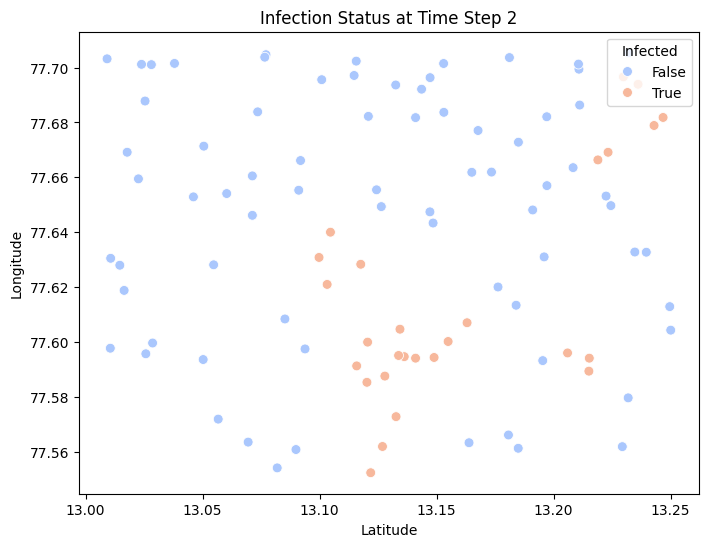

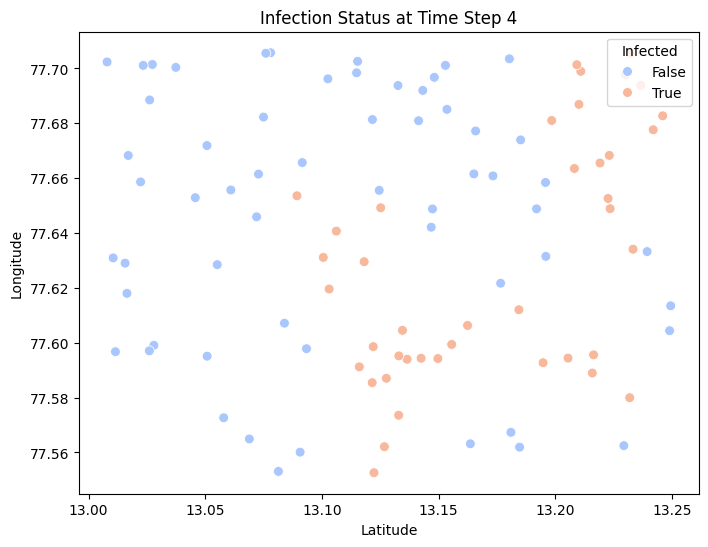

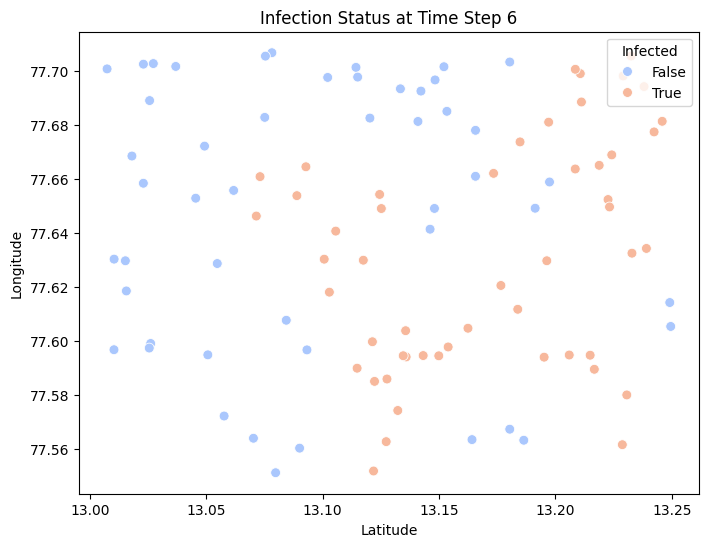

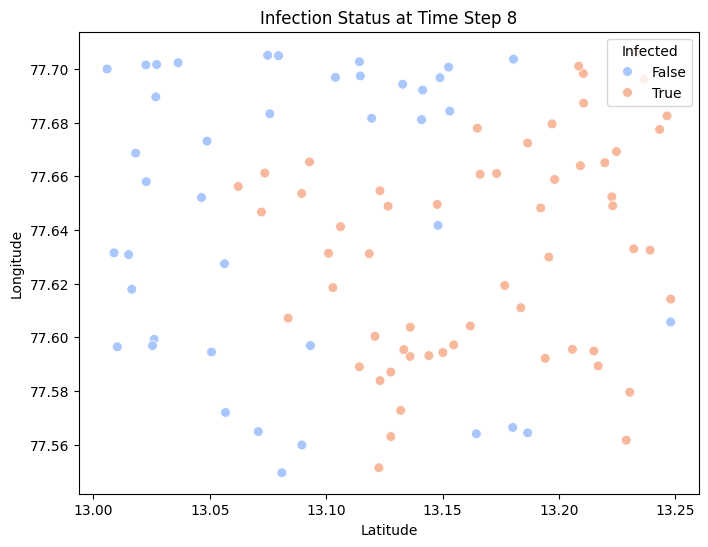

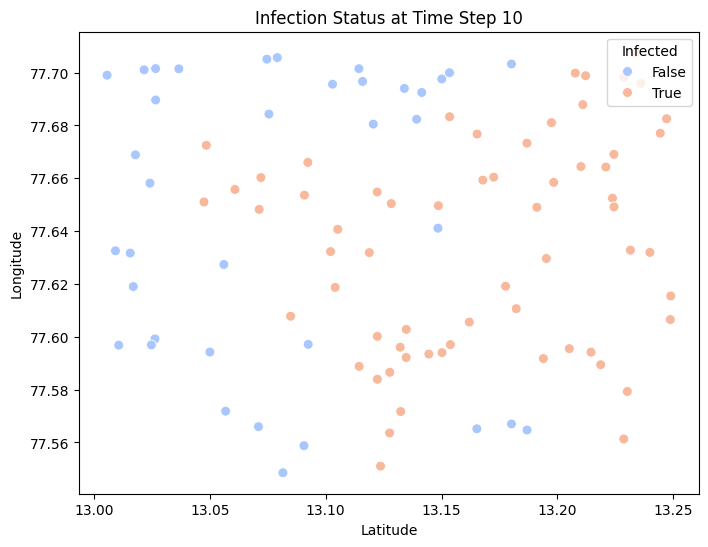


ML Infection Prediction Model Accuracy: 100.00%


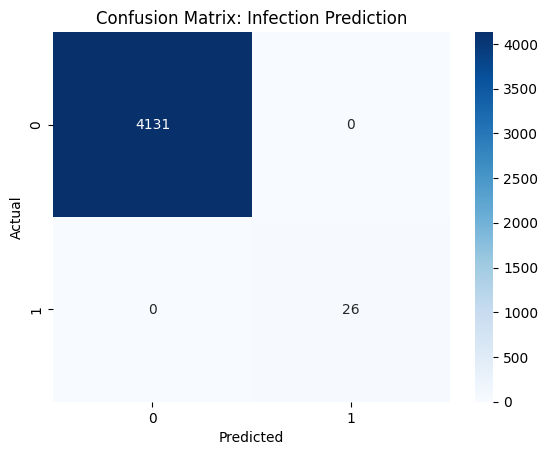


Infection counts per time step:
[np.int64(16), np.int64(27), np.int64(37), np.int64(41), np.int64(48), np.int64(51), np.int64(57), np.int64(59), np.int64(61), np.int64(63)]


In [ ]:
# ---------- Cell 6: Run the Simulation ----------
infected_counts, final_df, model = simulate_infection_with_ml(
    df.copy(),
    infection_radius=infection_radius,
    infection_prob=infection_prob,
    num_time_steps=time_steps,
    display_interval=2
)

print("\nInfection counts per time step:")
print(infected_counts)


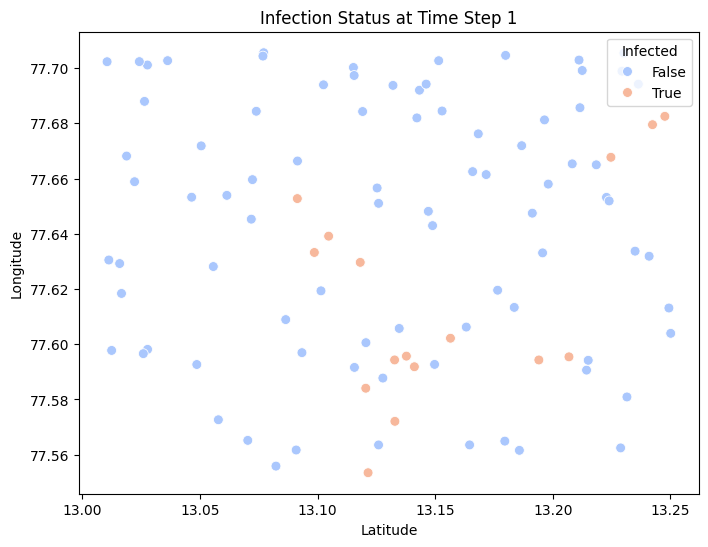

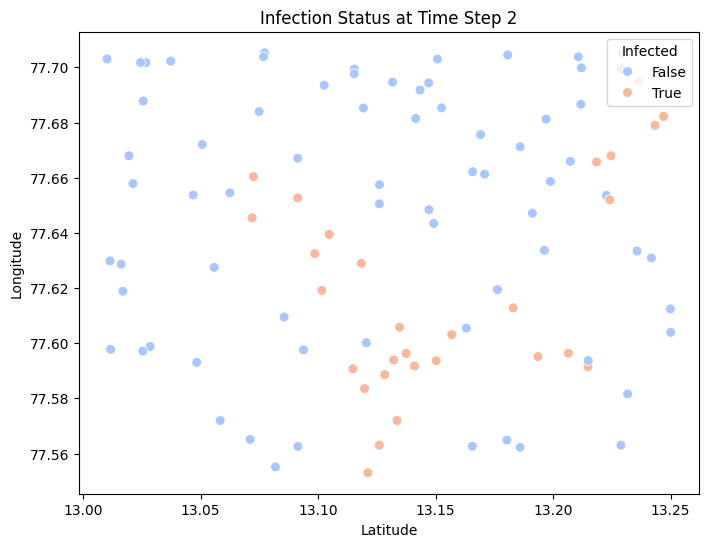

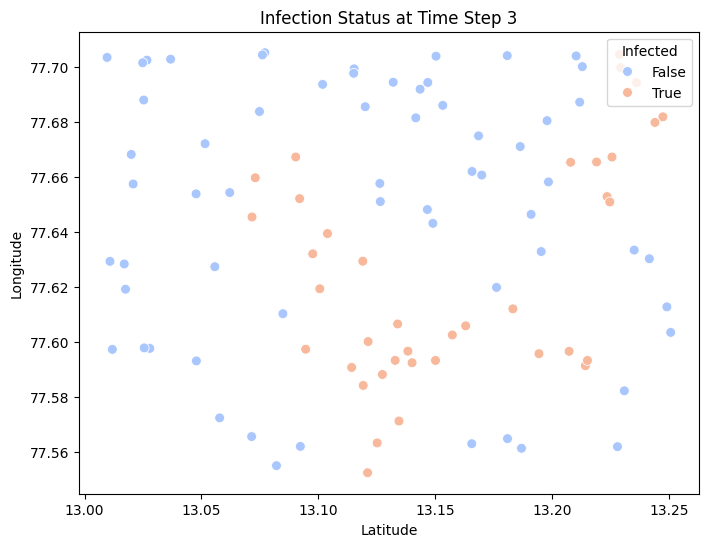

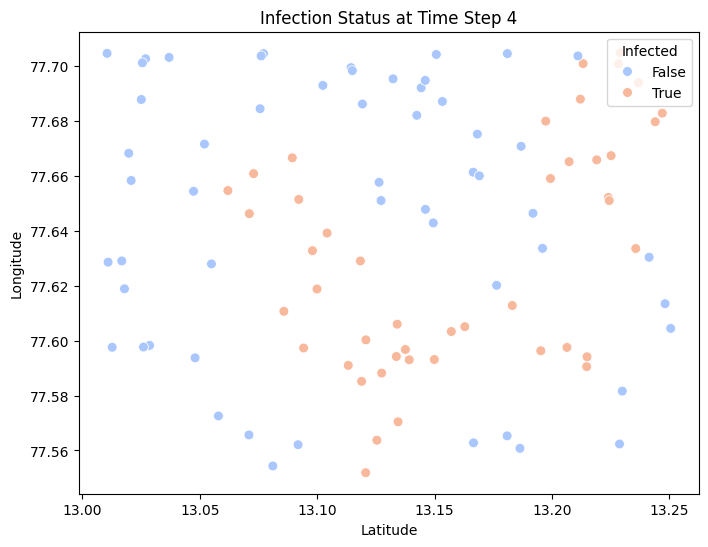

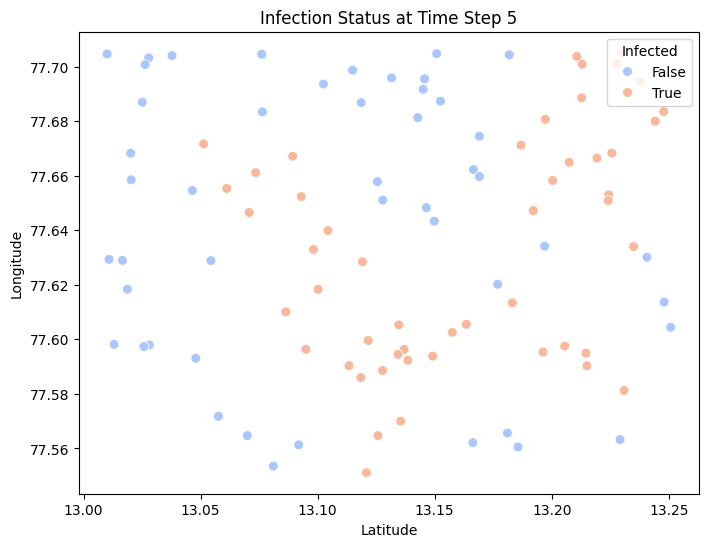

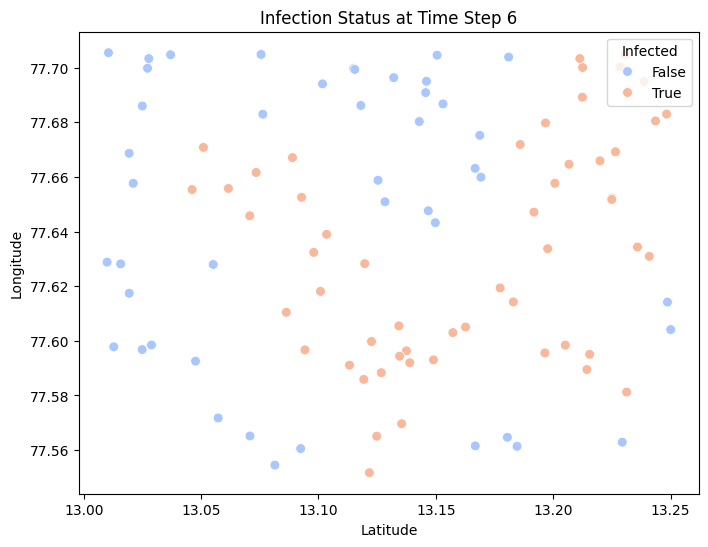

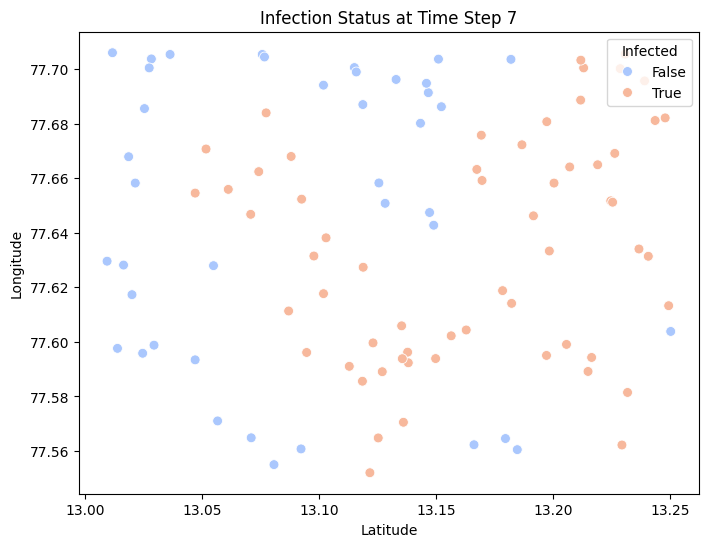

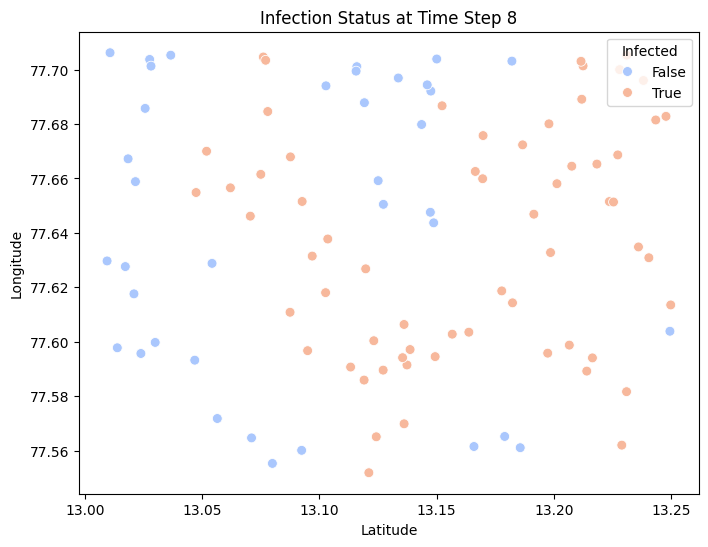

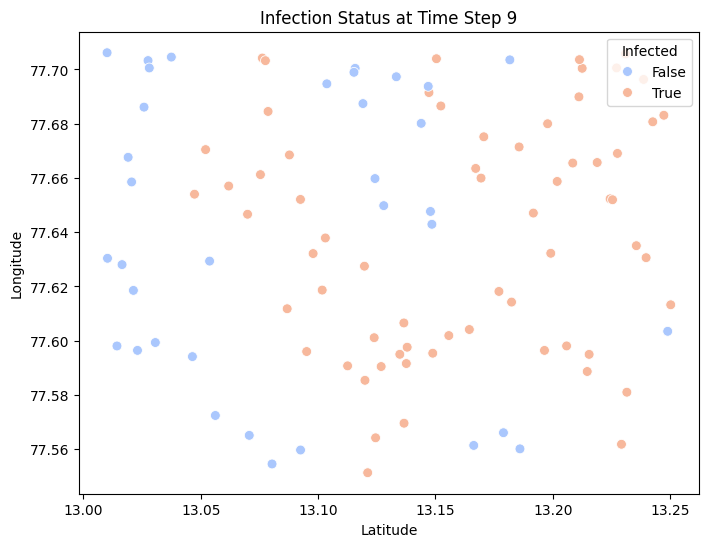

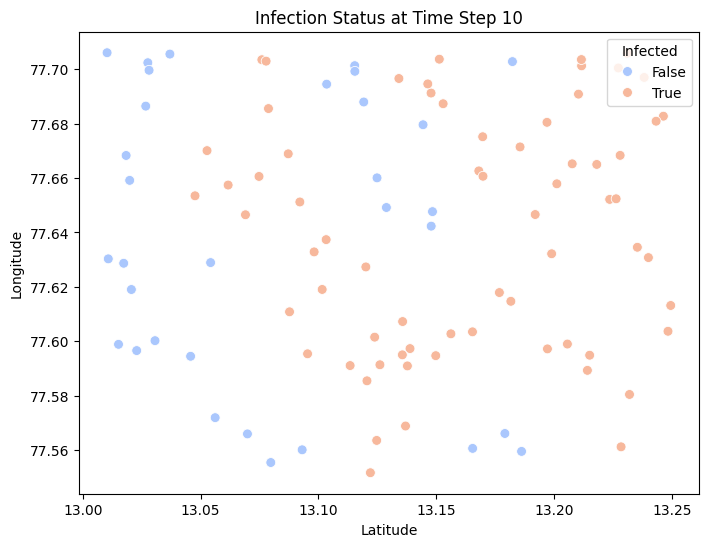

In [ ]:
# Run the simulation and generate plots for each time step
infected_counts = simulate_infection(
    df.copy(),  # Pass a copy to avoid modifying the original df in place
    infection_radius=infection_radius,
    infection_prob=infection_prob,
    num_time_steps=time_steps,
    display_interval=1  # Display a plot at each time step
)


Final number of infected individuals: 68
Percentage infected: 68.00% of population

List of Infected People:
       id   latitude  longitude
0   David  13.150188  77.593986
1   David  13.223728  77.652457
2   Frank  13.235975  77.695918
4    Ivan  13.230165  77.579275
6     Bob  13.224362  77.669071
..    ...        ...        ...
93  Alice  13.122306  77.583913
94  David  13.224405  77.649167
95   Judy  13.177621  77.619122
96    Bob  13.172523  77.660434
99  Alice  13.205105  77.595486

[63 rows x 3 columns]


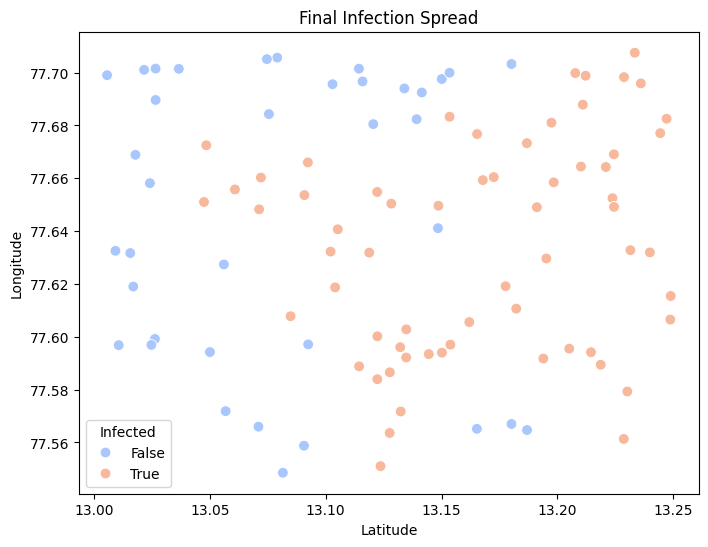

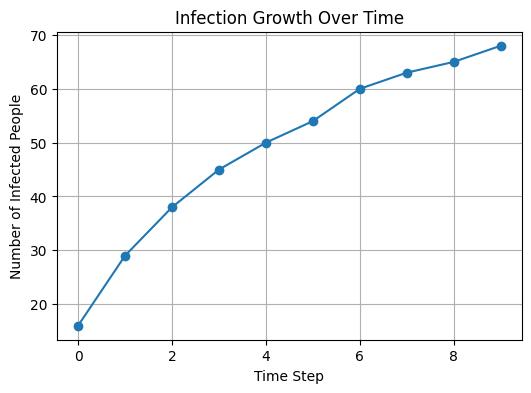

In [ ]:
# ---------- Cell 7: Final Summary and Plots ----------

final_infected = infected_counts[-1]
total = len(df)
percentage = (final_infected / total) * 100

print(f"\nFinal number of infected individuals: {final_infected}")
print(f"Percentage infected: {percentage:.2f}% of population")

# List of infected people
infected_people = final_df[final_df['infected']]
print("\nList of Infected People:")
print(infected_people[['id', 'latitude', 'longitude']])

# Final infection map
plt.figure(figsize=(8,6))
sns.scatterplot(x='latitude', y='longitude', data=final_df, hue='infected', palette='coolwarm', s=60)
plt.title("Final Infection Spread")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.legend(title="Infected", loc='best')
plt.show()

# Infection growth curve
plt.figure(figsize=(6,4))
plt.plot(range(len(infected_counts)), infected_counts, marker='o')
plt.title("Infection Growth Over Time")
plt.xlabel("Time Step")
plt.ylabel("Number of Infected People")
plt.grid(True)
plt.show()
